this file is for opening and plotting the data in the new h5 files

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


from hdf5_reader import HDF5Reader

In [2]:
reader = HDF5Reader()
reader.open_file('beamed_Air_Al_6061_Large_Plate_5.0mm.h5')

Successfully opened file: c:\Users\gerows\Python\SAIL-Plasma\BeAMED_v3\data\beamed_Air_Al_6061_Large_Plate_5.0mm.h5


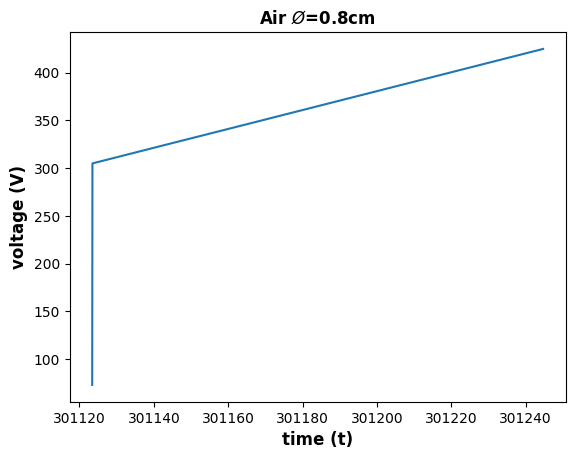

In [3]:
ax = reader.plot_discharge_timeseries(15)

In [10]:


with h5py.File('data/beamed_Air_Al_6061_Large_Plate_5.0mm.h5', mode='r') as f:
    #f.visit(print)
    print(list(f['discharges/discharge_002/critical data'].attrs))


['current_pwr', 'current_pwr_err', 'gap_cm', 'gap_err', 'pd_kjl_err', 'pd_mks_err', 'pressure_kjl', 'pressure_kjl_err', 'pressure_mks', 'pressure_mks_err', 'source', 'voltage_dmm', 'voltage_dmm_err', 'voltage_pwr', 'voltage_pwr_err']


KeyError: 'Unable to synchronously open object (invalid identifier type to function)'

In [29]:
vcr = []
pd = []
with h5py.File('data/beamed_Air_Al_6061_Large_Plate_5.0mm.h5', mode='r') as f:
    for key in f['discharges']:
        print(list(f['discharges'][key]['critical data'].attrs))
        vcr.append(f['discharges'][key]['critical data'].attrs['voltage_dmm'])
        pd.append(f['discharges'][key]['critical data'].attrs['pressure_mks']*f['discharges'][key]['critical data'].attrs['gap_cm'])
print(vcr)
print(pd)

['current_pwr', 'current_pwr_err', 'gap_cm', 'gap_err', 'pd_kjl_err', 'pd_mks_err', 'pressure_kjl', 'pressure_kjl_err', 'pressure_mks', 'pressure_mks_err', 'source', 'voltage_dmm', 'voltage_dmm_err', 'voltage_pwr', 'voltage_pwr_err']
['current_pwr', 'current_pwr_err', 'gap_cm', 'gap_err', 'pd_kjl_err', 'pd_mks_err', 'pressure_kjl', 'pressure_kjl_err', 'pressure_mks', 'pressure_mks_err', 'source', 'voltage_dmm', 'voltage_dmm_err', 'voltage_pwr', 'voltage_pwr_err']
['current_pwr', 'current_pwr_err', 'gap_cm', 'gap_err', 'pd_kjl_err', 'pd_mks_err', 'pressure_kjl', 'pressure_kjl_err', 'pressure_mks', 'pressure_mks_err', 'source', 'voltage_dmm', 'voltage_dmm_err', 'voltage_pwr', 'voltage_pwr_err']
['current_pwr', 'current_pwr_err', 'gap_cm', 'gap_err', 'pd_kjl_err', 'pd_mks_err', 'pressure_kjl', 'pressure_kjl_err', 'pressure_mks', 'pressure_mks_err', 'source', 'voltage_dmm', 'voltage_dmm_err', 'voltage_pwr', 'voltage_pwr_err']
['current_pwr', 'current_pwr_err', 'gap_cm', 'gap_err', 'pd_kjl_

In [30]:
pd = np.array(pd)
vcr = np.array(vcr)

In [31]:
pd = np.delete(pd, np.argmin(vcr))
pd = np.delete(pd, np.argmin(vcr))
vcr= np.delete(vcr, np.argmin(vcr))
vcr= np.delete(vcr, np.argmin(vcr))

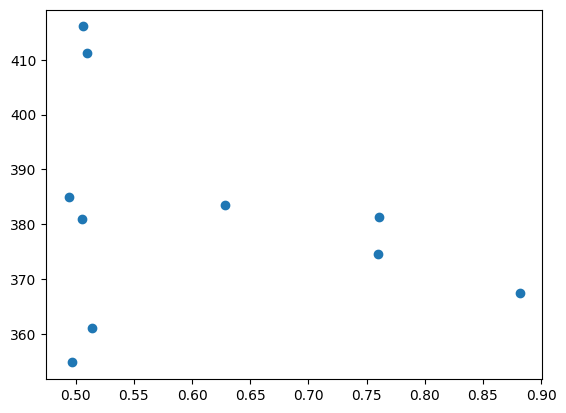

In [32]:

plt.scatter(pd, vcr)